# Fisher's Iris: From Four Measurements to One Score

**Voice-over:** “Let's use Fisher's own flowers.”

This notebook uses the classic Iris dataset bundled with scikit-learn. First we compare *versicolor* with *virginica* (50 flowers each), where the species overlap. Then we use all three species and show how LDA finds up to two discriminant directions.

The notebook computes every metric from the data. Cross-validation results can depend on the exact split and library version, so read the printed results rather than treating rounded narration figures as guarantees.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
feature_names = X.columns.tolist()
species_names = iris.target_names

print(f"Flowers: {len(X)} | measurements per flower: {len(feature_names)}")
print("Features:", ", ".join(feature_names))
print("Species counts:")
print(y.map(dict(enumerate(species_names))).value_counts().reindex(species_names))

Flowers: 150 | measurements per flower: 4
Features: sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)
Species counts:
target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Demo 1 — Versicolor vs. virginica

Setosa is comparatively easy to separate, so we focus on the two species that overlap. For each single measurement, the baseline predicts each flower using the midpoint between the two species' feature means. Then we fit LDA on all four measurements and classify by the midpoint of the projected class means.

In [2]:
pair_mask = y.isin([1, 2])
X_pair = X.loc[pair_mask].to_numpy()
y_pair = y.loc[pair_mask].to_numpy()
pair_names = species_names[1:]

single_feature_errors = {}
for column_index, feature in enumerate(feature_names):
    class_means = [X_pair[y_pair == class_id, column_index].mean() for class_id in (1, 2)]
    cutoff = np.mean(class_means)
    predictions = np.where(X_pair[:, column_index] > cutoff, 2, 1)
    single_feature_errors[feature] = int(np.sum(predictions != y_pair))

single_feature_table = pd.DataFrame({
    "Feature": feature_names,
    "Errors (out of 100)": [single_feature_errors[name] for name in feature_names],
}).sort_values("Errors (out of 100)").reset_index(drop=True)
display(single_feature_table)

pair_lda = LinearDiscriminantAnalysis(solver="svd")
pair_lda.fit(X_pair, y_pair)
direction = pair_lda.coef_[0].astype(float)
direction /= np.linalg.norm(direction)
if direction[feature_names.index("petal width (cm)")] < 0:
    direction *= -1  # LDA's axis sign is arbitrary; orient petal width positively.

class_scores = np.vstack([
    X_pair[y_pair == class_id] @ direction for class_id in (1, 2)
])
score_cutoff = class_scores.mean(axis=1).mean()
pair_scores = X_pair @ direction
pair_predictions = np.where(pair_scores > score_cutoff, 2, 1)
pair_errors = int(np.sum(pair_predictions != y_pair))

print("Unit-length Fisher direction (petal-width coefficient positive):")
print(pd.Series(direction, index=feature_names).round(2).to_string())
print(f"\nCombined-score training errors: {pair_errors} / {len(y_pair)}")
print("Caption: 4 numbers → 1 score → "
      f"{pair_errors} mistakes in 100")

,Feature,Errors (out of 100)
0,petal width (cm),6
1,petal length (cm),8
2,sepal length (cm),27
3,sepal width (cm),42


Unit-length Fisher direction (petal-width coefficient positive):
sepal length (cm)   -0.23
sepal width (cm)    -0.36
petal length (cm)    0.44
petal width (cm)     0.79

Combined-score training errors: 3 / 100
Caption: 4 numbers → 1 score → 3 mistakes in 100


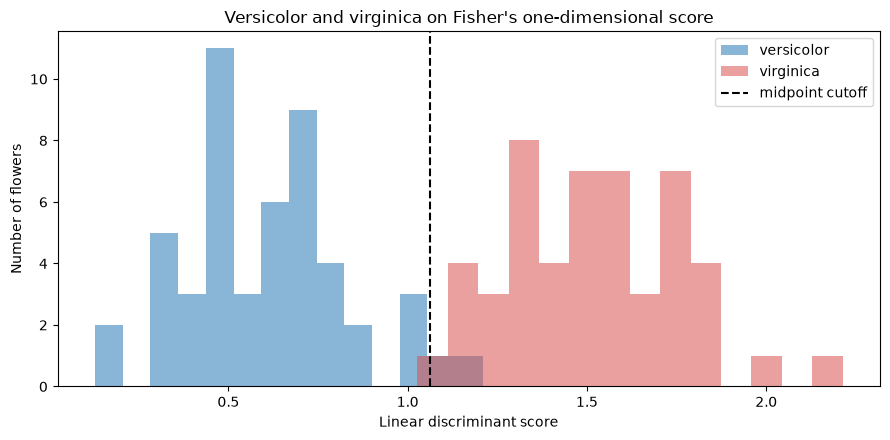

Stratified 5-fold CV accuracy: 97.0% (folds: 90%, 100%, 95%, 100%, 100%)
Leave-one-out accuracy: 97.0% (97/100 correct)


In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {1: "#2878B5", 2: "#D9534F"}
for class_id, name in zip((1, 2), pair_names):
    values = pair_scores[y_pair == class_id]
    ax.hist(values, bins=14, alpha=0.55, color=colors[class_id], label=name)
ax.axvline(score_cutoff, color="black", linestyle="--", label="midpoint cutoff")
ax.set(title="Versicolor and virginica on Fisher's one-dimensional score",
       xlabel="Linear discriminant score", ylabel="Number of flowers")
ax.legend()
fig.tight_layout()
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_model = make_pipeline(LinearDiscriminantAnalysis(solver="svd"))
cv_scores = cross_val_score(cv_model, X_pair, y_pair, cv=cv, scoring="accuracy")
loo_scores = cross_val_score(
    cv_model, X_pair, y_pair, cv=LeaveOneOut(), scoring="accuracy", n_jobs=-1
)

print(f"Stratified 5-fold CV accuracy: {cv_scores.mean():.1%} "
      f"(folds: {', '.join(f'{score:.0%}' for score in cv_scores)})")
print(f"Leave-one-out accuracy: {loo_scores.mean():.1%} "
      f"({int(loo_scores.sum())}/{len(loo_scores)} correct)")

## Demo 2 — All three species

With *K* classes, LDA can produce at most `min(number of features, K - 1)` discriminant directions. For three Iris species, that means no more than two. We fit the model to all 150 flowers, inspect its explained-discriminant variance and confusion matrix, and then score every flower in a leave-one-out fold.

In [4]:
multi_lda = LinearDiscriminantAnalysis(solver="svd", n_components=2)
multi_lda.fit(X, y)
multi_predictions = multi_lda.predict(X)
multi_accuracy = np.mean(multi_predictions == y)
confusion = pd.crosstab(
    pd.Categorical(y.map(dict(enumerate(species_names))), categories=species_names),
    pd.Categorical(pd.Series(multi_predictions, index=y.index).map(dict(enumerate(species_names))),
                   categories=species_names),
    rownames=["Actual"], colnames=["Predicted"], dropna=False
)

print(f"Maximum possible directions: min({X.shape[1]} features, 3 - 1 classes) = 2")
print("Explained discriminant variance:")
for index, proportion in enumerate(multi_lda.explained_variance_ratio_, start=1):
    print(f"  LD{index}: {proportion:.1%}")
print(f"\nTraining accuracy: {multi_accuracy:.1%} "
      f"({int(np.sum(multi_predictions == y))}/{len(y)} correct)")
print("\nConfusion matrix (rows = actual, columns = predicted):")
display(confusion)

multi_loo_scores = cross_val_score(
    LinearDiscriminantAnalysis(solver="svd", n_components=2),
    X.to_numpy(), y.to_numpy(), cv=LeaveOneOut(), scoring="accuracy", n_jobs=-1
)
print(f"Leave-one-out accuracy: {multi_loo_scores.mean():.1%} "
      f"({int(multi_loo_scores.sum())}/{len(multi_loo_scores)} correct)")

Maximum possible directions: min(4 features, 3 - 1 classes) = 2
Explained discriminant variance:
  LD1: 99.1%
  LD2: 0.9%

Training accuracy: 98.0% (147/150 correct)

Confusion matrix (rows = actual, columns = predicted):


Predicted,setosa,versicolor,virginica
Actual,,,
setosa,50,0,0
versicolor,0,48,2
virginica,0,1,49


Leave-one-out accuracy: 98.0% (147/150 correct)


,Mean LD1 score
setosa,7.68
versicolor,-1.84
virginica,-5.84


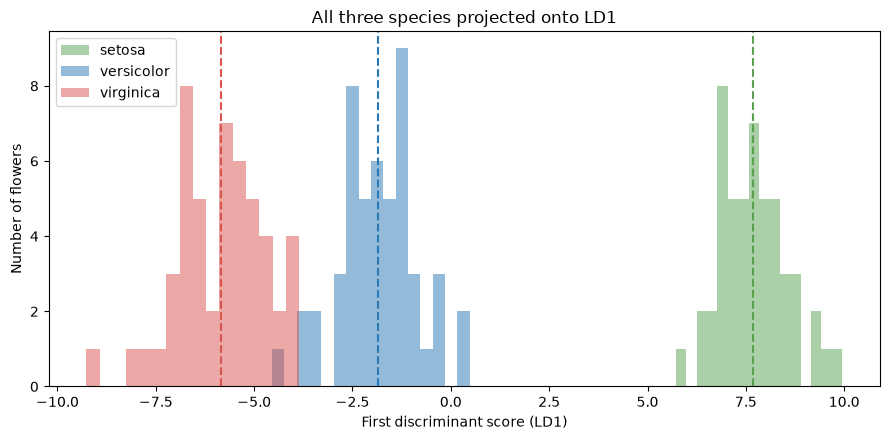

Caption: Same flowers Fisher used. Same answer, now one line of code.


In [5]:
ld1_scores = multi_lda.transform(X)[:, 0]
ld1_means = pd.Series({
    name: ld1_scores[y.to_numpy() == class_id].mean()
    for class_id, name in enumerate(species_names)
}, name="Mean LD1 score")
display(ld1_means.round(2).to_frame())

fig, ax = plt.subplots(figsize=(9, 4.5))
palette = ["#59A14F", "#2878B5", "#D9534F"]
for class_id, name, color in zip(range(3), species_names, palette):
    values = ld1_scores[y.to_numpy() == class_id]
    ax.hist(values, bins=16, alpha=0.5, color=color, label=name)
    ax.axvline(values.mean(), color=color, linestyle="--", linewidth=1.5)
ax.set(title="All three species projected onto LD1",
       xlabel="First discriminant score (LD1)", ylabel="Number of flowers")
ax.legend()
fig.tight_layout()
plt.show()
print("Caption: Same flowers Fisher used. Same answer, now one line of code.")

## What to take away

- **Combining measurements helps:** compare the four single-feature error counts with the four-feature LDA score. The score finds a linear combination that separates the two species better than any one measurement alone.
- **Petal measurements carry much of the signal:** inspect the fitted direction weights; their relative sizes show how each measurement contributes to this particular discriminant axis. The overall sign is arbitrary, which is why the two-class direction is oriented for display.
- **Evaluate on held-out flowers:** training errors describe the fitted sample. Stratified folds and leave-one-out refit the model without each evaluated flower, providing a less optimistic generalization estimate.
- **Three classes need at most two axes:** here LD1 captures most of the between-species separation; the LD1 means and score distributions show the species ordering while revealing remaining overlap.
- **Do not overpromise a fixed percentage:** results are calculated from scikit-learn's Iris data and the specified evaluation procedures. Small differences from narrated rounded figures can arise from evaluation protocol or library details.